In [67]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sb
import math
import numpy as np
import itertools

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [82]:
def eval_results(dset_name: str, analysis_name: str):
    results_dir = Path("results") / dset_name / analysis_name
    eval_result_dfs = []
    
    # baseline methods
    method_idx_for_color = 0
    for baseline_name in baseline_methods:
        tsv_path = results_dir / f"{baseline_name}.tsv"
        if not tsv_path.exists():
            print("Baseline result tsv does not exist: {}".format(tsv_path))
            continue
        method_name = baseline_name
        eval_result_dfs.append(
            pd.read_csv(tsv_path, sep='\t').assign(
                Method=method_name
            )
        )
    
    # torch models
    for embed_model in embed_models:
        for pred_idx, pred_model in enumerate(pred_models):
            tsv_path = results_dir / f"{embed_model}__{pred_model}.tsv"
            if not tsv_path.exists():
                print("Torch result tsv does not exist: {}".format(tsv_path))
                continue
            
            method_name = f'{embed_model}:{pred_model}'
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name
                )
            )
    
    
    return pd.concat(eval_result_dfs, ignore_index=True)

In [83]:
embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl', 'epc_nopool_kl']
baseline_methods = ['uniform', 'asv_nearest_neighbor']
baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]

In [84]:
v3v4_extended_df = eval_results("v3v4_split_multiproj_extended", "random_split")
# v3v4_original_df = eval_results("v3v4_split_multiproj")

# common_sids = set(v3v4_extended_df['SampleId']).intersection(set(v3v4_original_df['SampleId']))
# v3v4_extended_df = v3v4_extended_df.loc[v3v4_extended_df['SampleId'].isin(common_sids)]
# v3v4_original_df = v3v4_original_df.loc[v3v4_original_df['SampleId'].isin(common_sids)]

# both_df = pd.concat([
#     v3v4_extended_df.assign(Method=v3v4_extended_df['Method'].map(lambda _m: f'{_m}_EXT')), 
#     v3v4_original_df.assign(Method=v3v4_original_df['Method'].map(lambda _m: f'{_m}_ORIG')),
# ], axis=0, ignore_index=True)

Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/dnabert-s__epc_pool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/dnabert-s__epc_pool_3_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/dnabert-s__epc_nopool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo-1-8k-base_hyena5__epc_pool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo-1-8k-base_hyena5__epc_pool_3_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo-1-8k-base_hyena5__epc_nopool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo2_7b_hyena10__epc_pool_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multiproj_extended/random_split/evo2_7b_hyena10__epc_pool_3_kl.tsv
Torch result tsv does not exist: results/v3v4_split_multi

In [85]:
test_df = pd.read_csv("/data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/random_split/test.tsv", sep="\t")
display(test_df)

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region,read_counts
0,DRS182469,PRJDB10527,DRR247726,AMPLICON,METAGENOMIC,2021-04-27 15:51:54,97999670.0,Illumina MiSeq,"japan:tokyo, shinjuku",JP,Eastern and South-Eastern Asia,127173
1,DRS182480,PRJDB10527,DRR247737,AMPLICON,METAGENOMIC,2021-04-27 15:51:54,109832025.0,Illumina MiSeq,"japan:tokyo, shinjuku",JP,Eastern and South-Eastern Asia,162186
2,DRS182401,PRJDB10527,DRR247658,AMPLICON,METAGENOMIC,2021-04-27 15:51:53,132457242.0,Illumina MiSeq,"japan:tokyo, shinjuku",JP,Eastern and South-Eastern Asia,184451
3,DRS182479,PRJDB10527,DRR247736,AMPLICON,METAGENOMIC,2021-04-27 15:51:54,126284657.0,Illumina MiSeq,"japan:tokyo, shinjuku",JP,Eastern and South-Eastern Asia,182424
4,DRS182457,PRJDB10527,DRR247714,AMPLICON,METAGENOMIC,2021-04-27 15:51:54,93225876.0,Illumina MiSeq,"japan:tokyo, shinjuku",JP,Eastern and South-Eastern Asia,120813
...,...,...,...,...,...,...,...,...,...,...,...,...
2429,SRS9384058,PRJNA743361,SRR15032302,AMPLICON,METAGENOMIC,2021-07-03 16:05:39,2485658.0,Illumina MiSeq,usa: california,US,Europe and Northern America,7474
2430,SRS9384054,PRJNA743361,SRR15032305,AMPLICON,METAGENOMIC,2021-07-03 16:05:39,4296173.0,Illumina MiSeq,usa: california,US,Europe and Northern America,12070
2431,SRS9384057,PRJNA743361,SRR15032301,AMPLICON,METAGENOMIC,2021-07-03 16:00:56,2661141.0,Illumina MiSeq,usa: california,US,Europe and Northern America,7807
2432,SRS9383985,PRJNA743361,SRR15032397,AMPLICON,METAGENOMIC,2021-07-03 16:01:48,7799211.0,Illumina MiSeq,usa: california,US,Europe and Northern America,23739


In [ ]:
v3v4_extended_df = v3v4_extended_df.merge(
    test_df[['srs', 'project']],
    left_on='SampleId', right_on='srs', how='inner'
)

In [92]:
display(v3v4_extended_df)

,SampleId,KL_err,RMSL_err,SpearmanCorr,BrayCurtis,RootJensenShannon,NumSGB,Method,srs,project
0,DRS182469,1.669657,0.947037,NaN,0.649873,0.546129,181,uniform,DRS182469,PRJDB10527
1,DRS182480,1.467664,0.985551,NaN,0.595653,0.524473,169,uniform,DRS182480,PRJDB10527
2,DRS182401,1.422430,1.202717,NaN,0.671413,0.557716,152,uniform,DRS182401,PRJDB10527
3,DRS182479,2.222795,1.310791,NaN,0.750665,0.626298,141,uniform,DRS182479,PRJDB10527
4,DRS182457,1.227731,0.927105,NaN,0.590796,0.501534,206,uniform,DRS182457,PRJDB10527
...,...,...,...,...,...,...,...,...,...,...
29143,SRS9384058,0.139178,0.293985,0.712074,0.216161,0.189101,65,evo2_7b_hyena10:epc_pool_2_kl,SRS9384058,PRJNA743361
29144,SRS9384054,0.155148,0.290196,0.572809,0.227936,0.196378,82,evo2_7b_hyena10:epc_pool_2_kl,SRS9384054,PRJNA743361
29145,SRS9384057,0.147375,0.289158,0.558115,0.210290,0.192985,60,evo2_7b_hyena10:epc_pool_2_kl,SRS9384057,PRJNA743361
29146,SRS9383985,0.082083,0.180106,0.703233,0.152169,0.140254,180,evo2_7b_hyena10:epc_pool_2_kl,SRS9383985,PRJNA743361


Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.


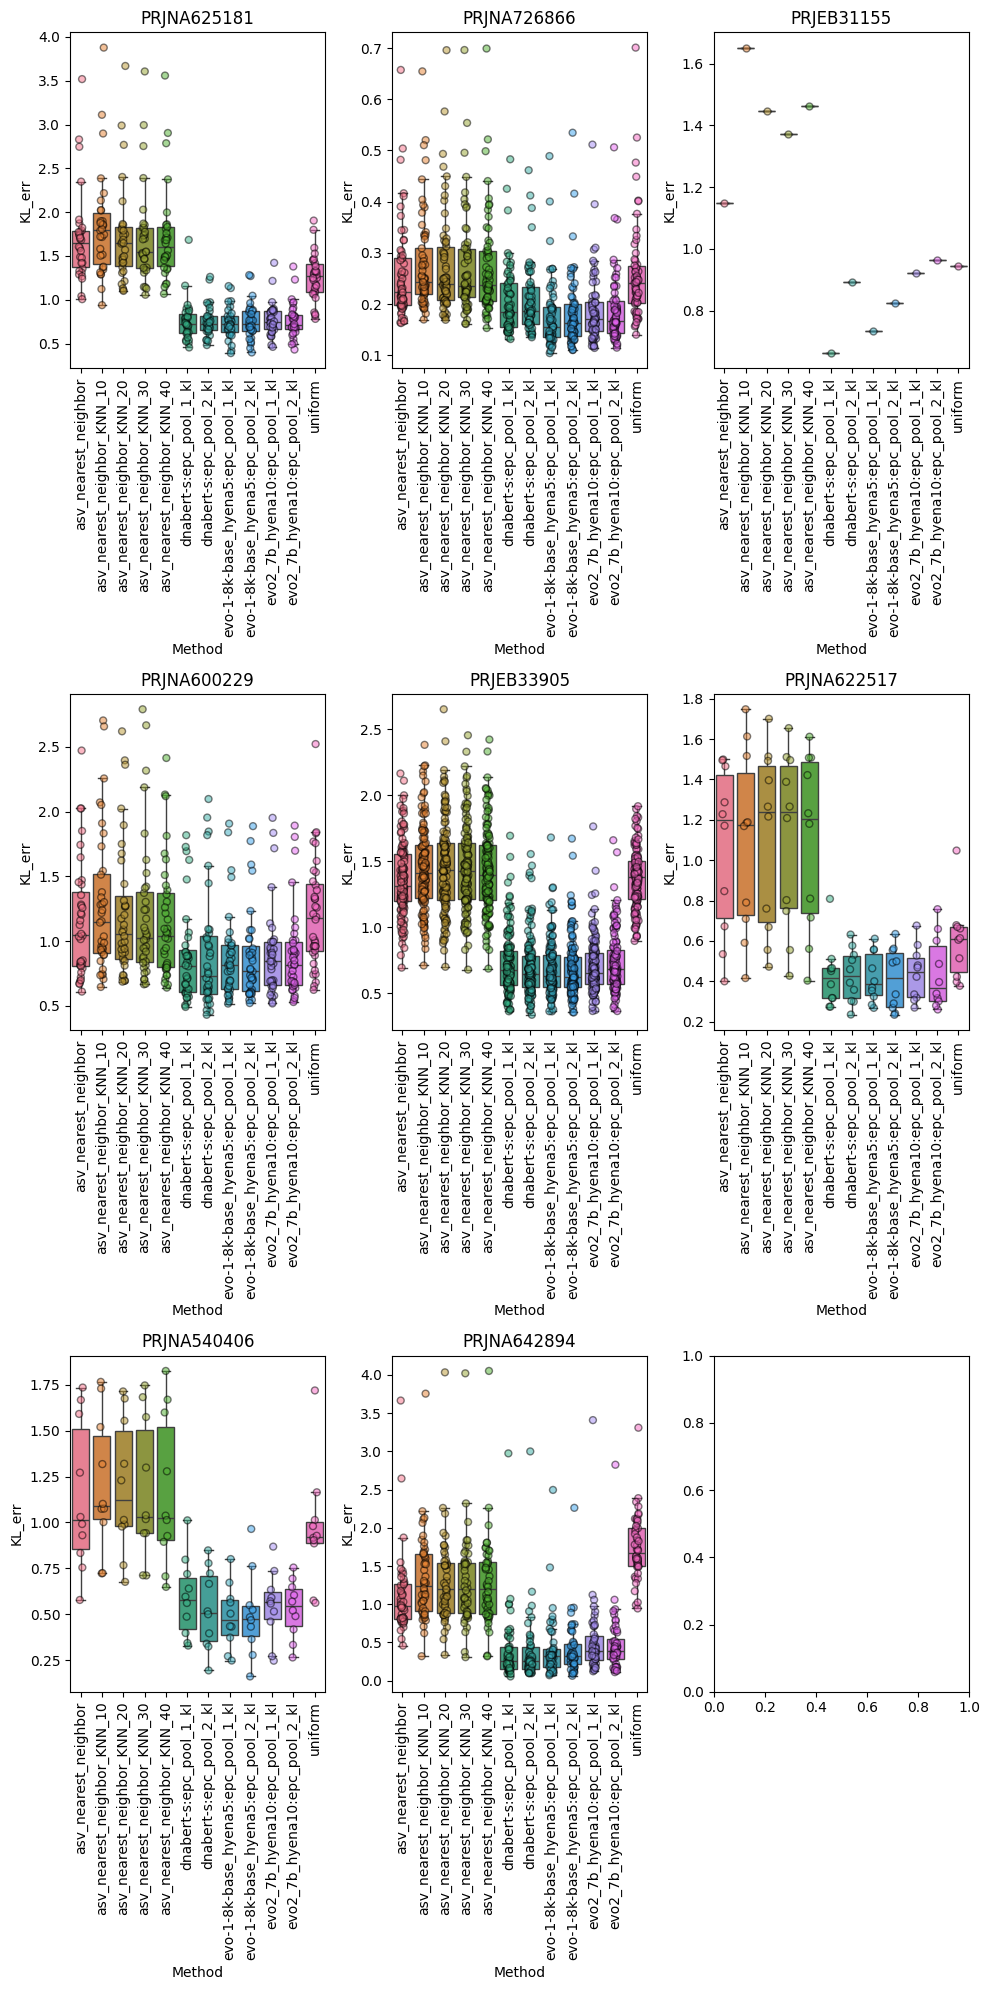

In [97]:
import math
proj_subset = set(v3v4_extended_df['project']).intersection({
    "PRJNA726866", "PRJNA622517", "PRJNA540406", "PRJNA625181", "PRJNA642894", "PRJEB33905", "PRJEB31155", "PRJNA600229", "PRJNA644097"
})


n_cols = 3
n_rows = math.ceil(len(proj_subset) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 20))
axes = axes.flatten()
for proj, ax in zip(proj_subset, axes):
    boxplot_with_paired_significance(
        data=v3v4_extended_df.loc[v3v4_extended_df['project'] == proj],
        hue='Method',
        y='KL_err',
        sample_col='SampleId',
        ax=ax,
    )
    ax.set_title(proj)
    

In [91]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, annot_pvals: bool = False, ax=None, hue_order=None, palette=None, correction='fdr_bh'):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.5, edgecolor='black', linewidth=1.0)
    ax.set_xticks(range(len(hue_order)))
    ax.set_xticklabels(hue_order, rotation=90)

    if annot_pvals:
        # Get y-axis range for proper scaling
        ylim = ax.get_ylim()
        y_range = ylim[1] - ylim[0]
        y_max = data[y].max()
        
        # Starting position for annotations (4% above data max)
        y_start = y_max + y_range * 0.04
        
        # Pairwise significance testing
        pairs = list(itertools.combinations(hue_order, 2))
        p_values = []
        test_results = []
        
        # Collect all p-values first
        for h1, h2 in pairs:
            d1 = data[data[hue] == h1][[sample_col, y]]
            d2 = data[data[hue] == h2][[sample_col, y]]
            joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
            v1 = joined[y + '_1']
            v2 = joined[y + '_2']
            stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
            p_values.append(p)
            test_results.append((h1, h2, stat, p))
        
        # Apply multiple hypothesis correction
        if len(p_values) > 1:
            rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
        else:
            rejected = [p_values[0] < 0.05] if p_values else []
            p_corrected = p_values
        
        # Annotation with corrected p-values
        annotation_idx = 0  # Counter for positioning annotations
        for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
            p_adj = p_corrected[idx]
            
            stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
            
            x1, x2 = group_locs[h1], group_locs[h2]
            
            # Calculate bracket position and height based on y-axis range
            y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
            bracket_height = y_range * 0.02  # 2% of y-range for bracket height
            text_offset = y_range * 0.001  # offset for text above bracket
            
            # Draw significance bracket
            ax.plot([x1, x1, x2, x2], 
                    [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                    lw=1.2, c='k')
            
            # Add significance text with adjusted p-value info
            text = f"{stars}"
            ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                    text, ha='center', va='bottom', color='k', fontsize=11)
            
            annotation_idx += 1
        
        # Add correction method info to plot
        ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    else:
        print("Skipping p-value annotation.")
    
    plt.tight_layout()
    return ax

Skipping p-value annotation.


<Axes: xlabel='Method', ylabel='KL_err'>

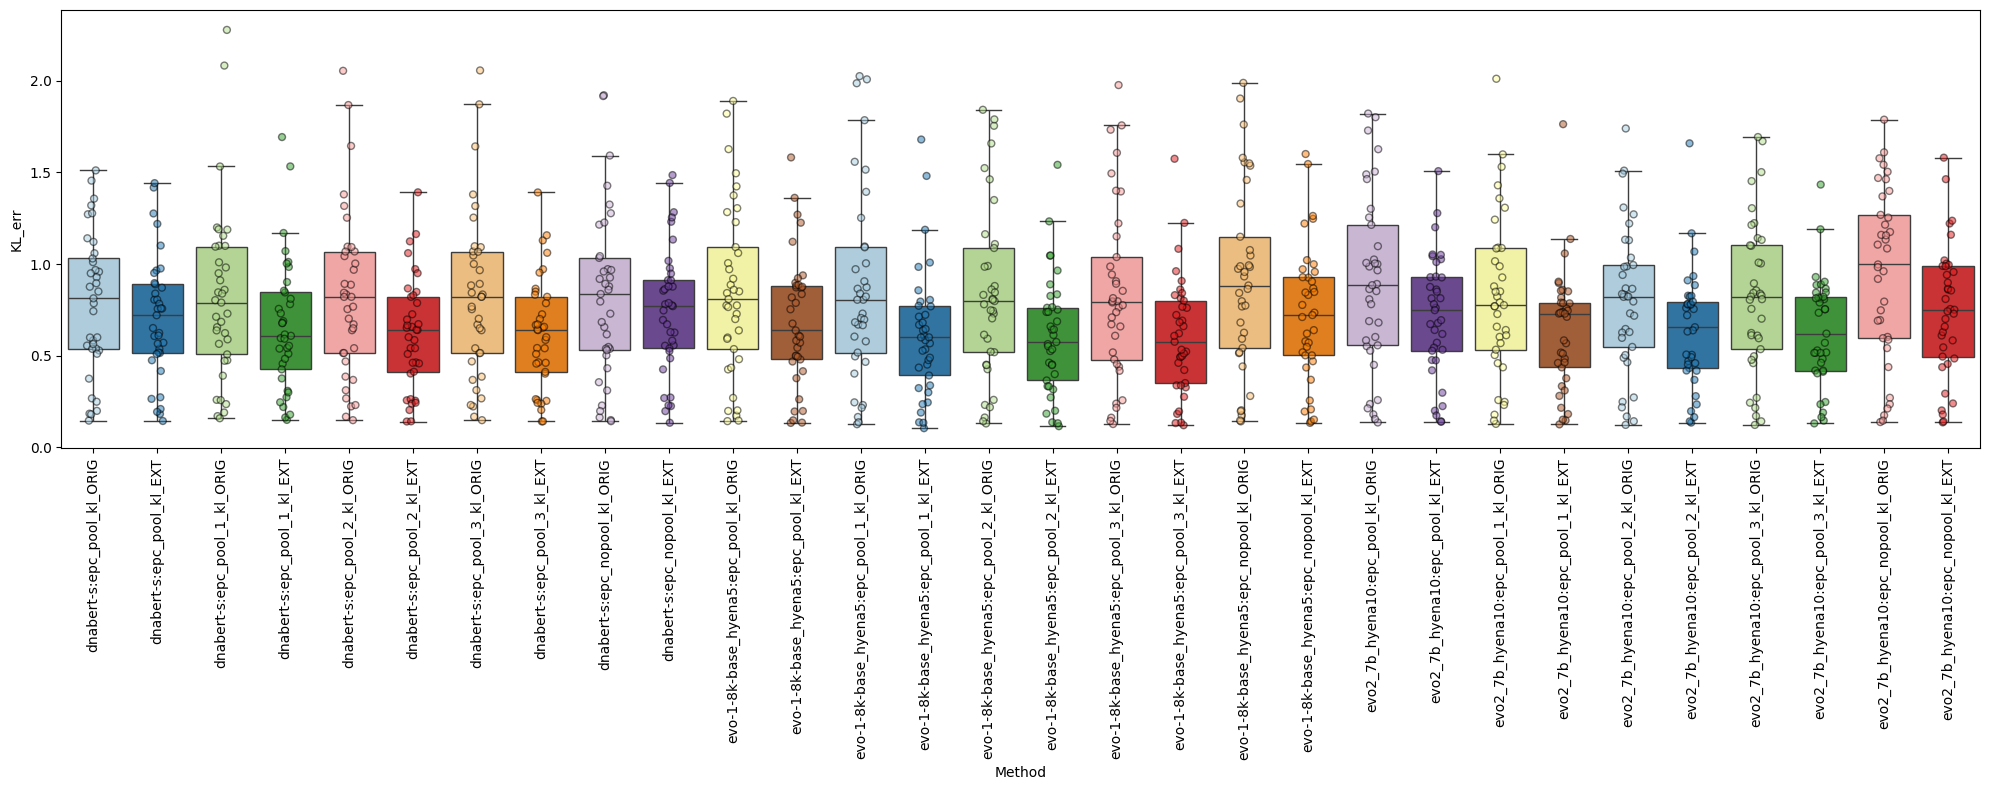

In [42]:
color_arr = sb.color_palette("Paired", 30)
method_order = []
plot_palette = {}
color_iter = iter(color_arr)
for embed_mdl in embed_models:
    for pred_mdl in pred_models:
        m1 = f'{embed_mdl}:{pred_mdl}_ORIG'
        m2 = f'{embed_mdl}:{pred_mdl}_EXT'
        method_order += [m1, m2]
        plot_palette[m1] = next(color_iter)
        plot_palette[m2] = next(color_iter)
        
# embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl', 'epc_nopool_kl']

fig, ax = plt.subplots(1, 1, figsize=(20, 8))
boxplot_with_paired_significance(
    both_df, hue='Method', y='KL_err', sample_col='SampleId', hue_order=method_order, palette=plot_palette, ax=ax
)

n plots = 15


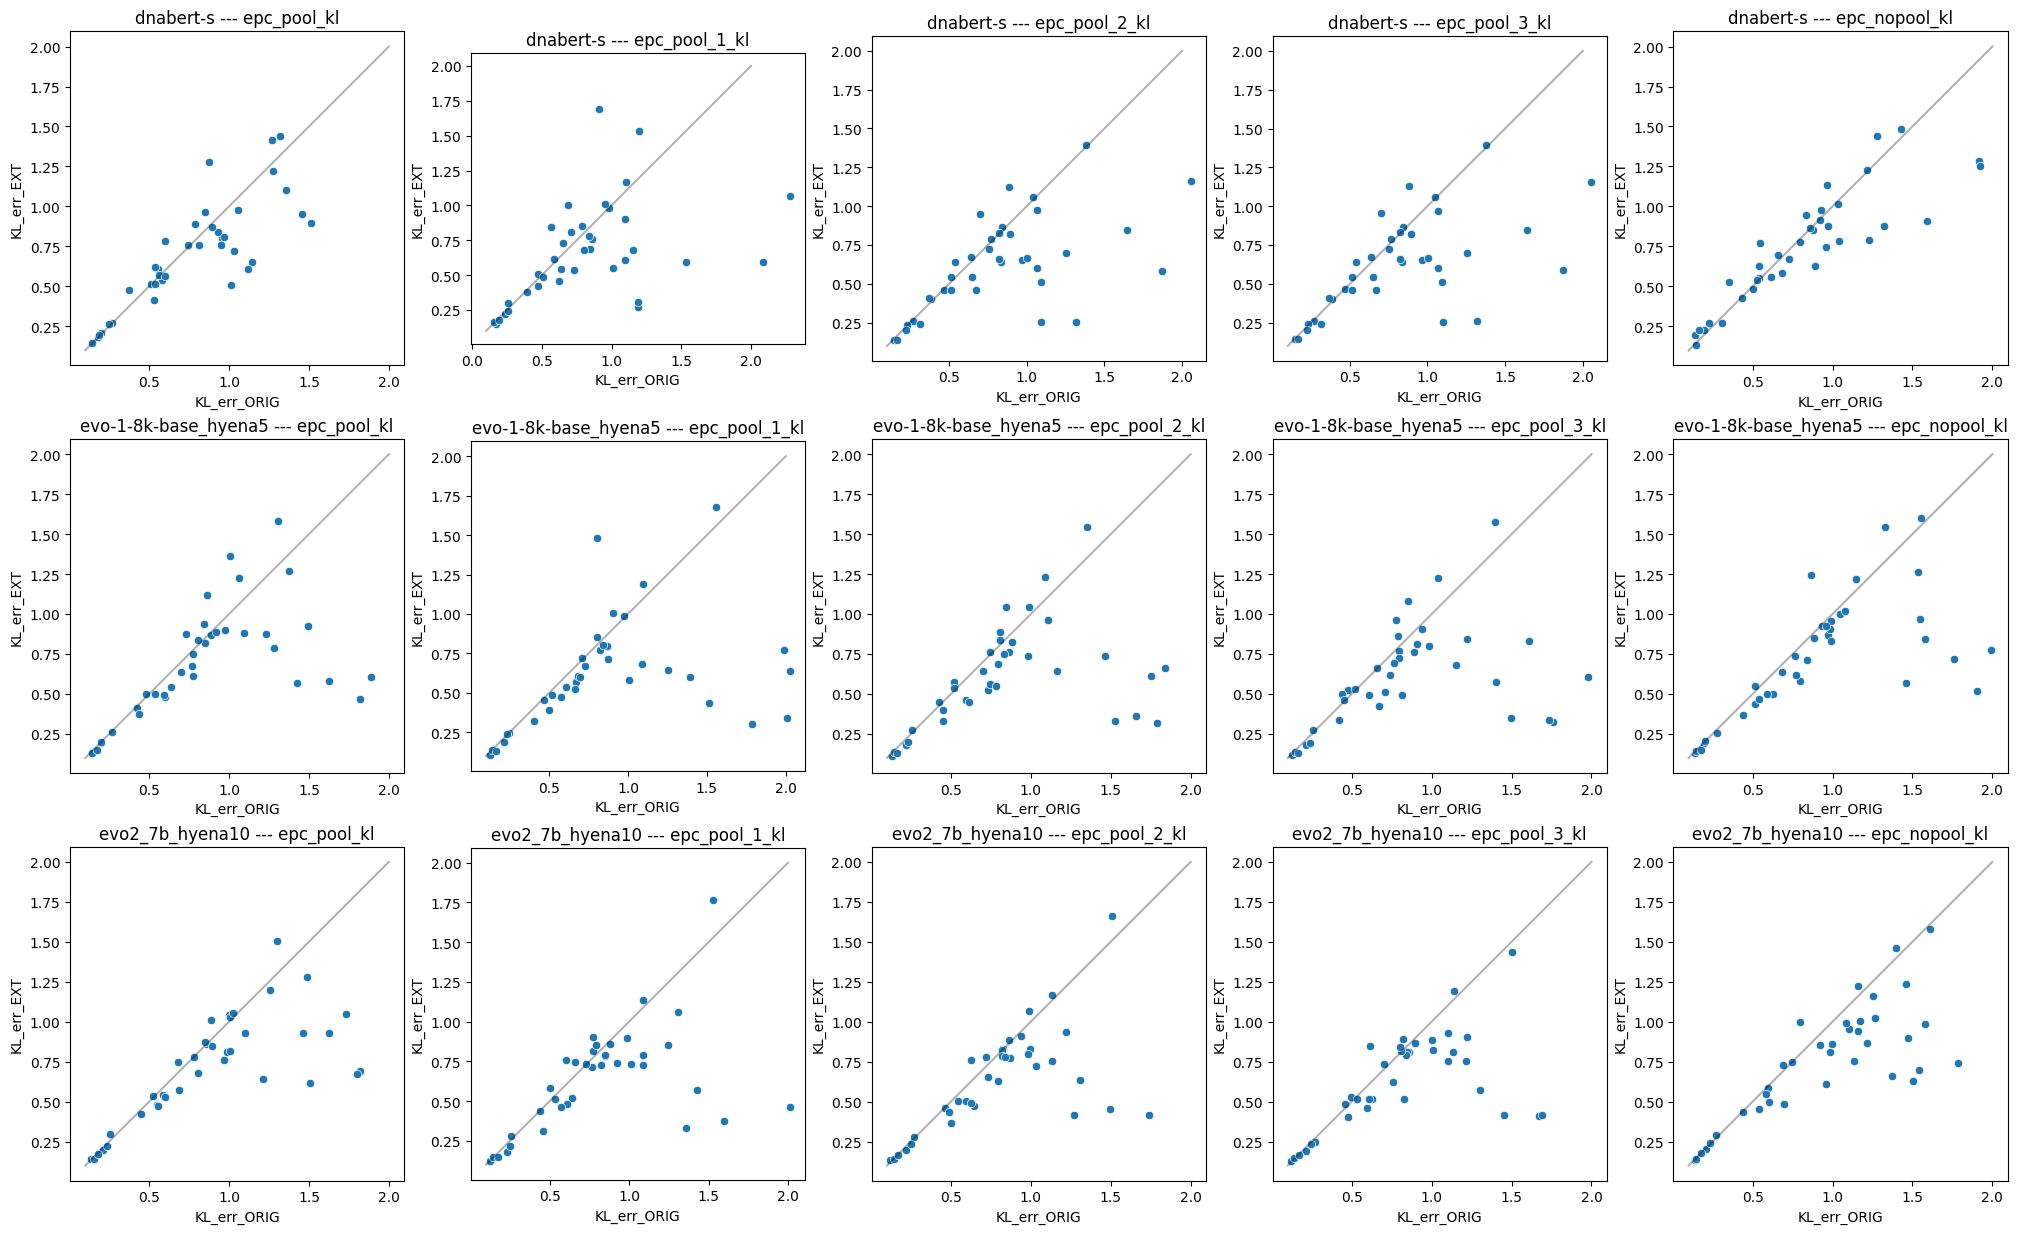

In [66]:
n_plots = len(embed_models) * len(pred_models)
print(f"n plots = {n_plots}")

n_rows = 3
n_cols = math.ceil(n_plots / 3)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = axes.flatten()
for ax in axes[n_plots:]:
    ax.axis('off')

for ax, (embed_mdl, pred_mdl) in zip(axes, itertools.product(embed_models, pred_models)):
    method_name = f'{embed_mdl}:{pred_mdl}'
    ax.set_title(f'{embed_mdl} --- {pred_mdl}')
    
    sec1 = v3v4_extended_df.loc[v3v4_extended_df['Method'] == method_name]
    sec2 = v3v4_original_df.loc[v3v4_original_df['Method'] == method_name]

    ax.set_aspect('equal', adjustable='box')
    ax.plot([0.1, 2.0], [0.1, 2.0], color='black', alpha=0.3)
    sb.scatterplot(
        data=sec1.merge(sec2, on='SampleId', how='inner', suffixes=['_EXT', '_ORIG']),
        x='KL_err_ORIG', y='KL_err_EXT', ax=ax
    )